# Residual GAN Augmentation (Raw Waveform) – Excavation Only
Bu notebook **sequences.py'ye dokunmadan** excavation class'ı için **residual GAN** eğitir ve augmentation çıktısını görselleştirir.

**Önemli:** Bu süreç raw waveform ile çalışır ama GAN eğitiminde *residual normalizasyonu* kullanır (normalize → GAN → denormalize). Aksi halde GAN residual RMS'i 1 civarına çakılır (senin yaşadığın durum).

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sequences import _load_sequence_dataframe, _load_signal_from_row
from config import load_class_info
from pathlib import Path

2025-12-16 13:46:00.541139: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-16 13:46:00.541203: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-16 13:46:00.567748: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-16 13:46:00.614885: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# CELL 2 — Ayarlar (burayı değiştirmen yeter)
DATA_FOLDER = Path("/tf/start_training/data/signal/2026-02-11-walking-with-peaks")
LABEL = "excavation"

WINDOW_SIZE = 20000
LATENT_CH   = 8          # z kanalı (çok büyük tutma)
BATCH       = 8
LR          = 2e-4
STEPS       = 4000
LOG_EVERY   = 100

# Loss ağırlıkları (başlangıç)
W_ENV   = tf.constant(1.0, dtype=tf.float32)
W_ONSET= tf.constant(0.5, dtype=tf.float32)
W_AC   = tf.constant(0.3, dtype=tf.float32)
W_DELTA= tf.constant(0.005, dtype=tf.float32)
W_PEAK = tf.constant(0.3, dtype=tf.float32)



2025-12-16 13:46:05.022629: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-16 13:46:05.061223: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-16 13:46:05.062728: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [4]:
# CELL 3 — CSV ve excavation filtre
df = _load_sequence_dataframe(DATA_FOLDER / "train.csv")
class_info = load_class_info(DATA_FOLDER)
classes = class_info.classes

exc_df = df[df["event"] == LABEL].reset_index(drop=True)

print("Classes:", classes)
print("Train samples:", len(df))
print(f"{LABEL} samples:", len(exc_df))
assert len(exc_df) >= 2*BATCH, "Excavation verisi çok az. BATCH düşür veya daha fazla veri kullan."


Classes: ['car', 'digging', 'excavation', 'noise', 'walking']
Train samples: 74792
Excavation samples: 16223


In [5]:
def sample_exc_batch(exc_df, batch=BATCH, window=WINDOW_SIZE):
    rows_src = exc_df.sample(batch, replace=True).to_dict("records")
    rows_tgt = exc_df.sample(batch, replace=True).to_dict("records")

    xs, xt = [], []
    for rs, rt in zip(rows_src, rows_tgt):
        xsig = _load_signal_from_row(rs, window).astype(np.float32)
        tsig = _load_signal_from_row(rt, window).astype(np.float32)
        xs.append(xsig)
        xt.append(tsig)

    xs = np.stack(xs, axis=0)[:, :, None]  # (B,T,1)
    xt = np.stack(xt, axis=0)[:, :, None]  # (B,T,1)
    return xs, xt


In [6]:
def moving_avg(x, k=129):
    # x: (B,T,1)
    x = tf.squeeze(x, -1)                 # (B,T)
    x = x[:, :, None]                     # (B,T,1)
    filt = tf.ones([k, 1, 1], tf.float32) / float(k)
    y = tf.nn.conv1d(x, filt, stride=1, padding="SAME")
    return y  # (B,T,1)

def envelope(x):
    # abs + smoothing (Hilbert yerine daha stabil)
    return moving_avg(tf.abs(x), k=129)

def onset(env):
    # vuruş başlangıcı: env türevi
    d = env[:, 1:, :] - env[:, :-1, :]
    d = tf.nn.relu(d)
    # eski boyuta pad
    return tf.pad(d, [[0,0],[0,1],[0,0]])

def autocorr_1d(x, max_lag=2000):
    # x: (B,T,1) -> env üzerinden kullanacağız
    x = tf.squeeze(x, -1)                # (B,T)
    x = x - tf.reduce_mean(x, axis=1, keepdims=True)
    # FFT tabanlı autocorr: irfft(|X|^2)
    X = tf.signal.rfft(x)
    S = tf.math.conj(X) * X
    ac = tf.signal.irfft(S)
    ac = ac[:, :max_lag]
    ac = ac / (ac[:, :1] + 1e-12)
    return ac  # (B,max_lag)


In [7]:
def mask_signal(x, drop_frac=0.3):
    mask = tf.cast(tf.random.uniform(tf.shape(x)) > drop_frac, tf.float32)
    return x * mask

def build_cond_generator(window=WINDOW_SIZE, latent_ch=LATENT_CH):
    x_in = tf.keras.Input(shape=(window,1), name="x_src")
    z_in = tf.keras.Input(shape=(window,latent_ch), name="z")

    x_masked = tf.keras.layers.Lambda(lambda t: mask_signal(t, 0.4))(x_in)
    h = tf.keras.layers.Concatenate()([x_masked, z_in])
    h = tf.keras.layers.Conv1D(64, 25, padding="same")(h)
    h = tf.keras.layers.LeakyReLU(0.2)(h)
    h = tf.keras.layers.Conv1D(128, 25, padding="same")(h)
    h = tf.keras.layers.LeakyReLU(0.2)(h)
    h = tf.keras.layers.Conv1D(128, 25, padding="same")(h)
    h = tf.keras.layers.LeakyReLU(0.2)(h)
    h = tf.keras.layers.Conv1D(64, 25, padding="same")(h)
    h = tf.keras.layers.LeakyReLU(0.2)(h)

    delta = tf.keras.layers.Conv1D(1, 25, padding="same", activation="tanh")(h)
    # delta’yı küçük başlatmak için ölçek
    delta = tf.keras.layers.Lambda(lambda t: 0.2 * t)(delta)
    return tf.keras.Model([x_in, z_in], delta, name="cond_excavation_delta_gen")

GEN = build_cond_generator()
opt = tf.keras.optimizers.Adam(LR)
GEN.summary()


Model: "cond_excavation_delta_gen"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 x_src (InputLayer)          [(None, 20000, 1)]           0         []                            
                                                                                                  
 lambda (Lambda)             (None, 20000, 1)             0         ['x_src[0][0]']               
                                                                                                  
 z (InputLayer)              [(None, 20000, 8)]           0         []                            
                                                                                                  
 concatenate (Concatenate)   (None, 20000, 9)             0         ['lambda[0][0]',              
                                                                     'z[0]

In [8]:
def loss_env(fake, tgt):
    ef = envelope(fake)
    et = envelope(tgt)
    return tf.reduce_mean(tf.abs(ef - et))

def loss_onset(fake, tgt):
    of = onset(envelope(fake))
    ot = onset(envelope(tgt))
    return tf.reduce_mean(tf.abs(of - ot))

def loss_ac(fake, tgt, max_lag=2000):
    af = autocorr_1d(envelope(fake), max_lag=max_lag)
    at = autocorr_1d(envelope(tgt),  max_lag=max_lag)
    return tf.reduce_mean(tf.abs(af - at))

def loss_delta(delta):
    # delta enerji reg (noise’a kaçmayı frenler)
    return tf.reduce_mean(tf.square(delta))
def peak_distance_loss(fake, tgt):
    ef = envelope(fake)
    et = envelope(tgt)
    pf = tf.where(ef > 0.7 * tf.reduce_max(ef, axis=1, keepdims=True))
    pt = tf.where(et > 0.7 * tf.reduce_max(et, axis=1, keepdims=True))
    loss_value = tf.abs(tf.reduce_mean(pf[:,1]) - tf.reduce_mean(pt[:,1]))

    return tf.cast(loss_value, tf.float32)


In [9]:
@tf.function
def train_step(x_src, x_tgt):
    z = tf.random.normal((tf.shape(x_src)[0], WINDOW_SIZE, LATENT_CH))

    with tf.GradientTape() as tape:
        delta = GEN([x_src, z], training=True)
        x_fake = x_src + delta

        le = loss_env(x_fake, x_tgt)
        lo = loss_onset(x_fake, x_tgt)
        la = loss_ac(x_fake, x_tgt, max_lag=2000)
        ld = loss_delta(delta)
        lpd = peak_distance_loss(x_fake, x_tgt)
        total = (
        W_ENV   * le +
        W_ONSET* lo +
        W_AC   * la +
        W_DELTA* ld +
        W_PEAK * lpd
        )


    grads = tape.gradient(total, GEN.trainable_variables)
    opt.apply_gradients(zip(grads, GEN.trainable_variables))
    return total, le, lo, la, ld, lpd


In [10]:
hist = {"total":[], "env":[], "onset":[], "ac":[], "delta":[]}

for step in range(STEPS):
    xs, _  = sample_exc_batch(exc_df, batch=BATCH, window=WINDOW_SIZE)
    _,  xt = sample_exc_batch(exc_df, batch=BATCH, window=WINDOW_SIZE)
    xs = tf.convert_to_tensor(xs)
    xt = tf.convert_to_tensor(xt)

    total, le, lo, la, ld, lpd = train_step(xs, xt)

    hist["total"].append(float(total))
    hist["env"].append(float(le))
    hist["onset"].append(float(lo))
    hist["ac"].append(float(la))
    hist["delta"].append(float(ld))

    if step % LOG_EVERY == 0:
        print(f"[{step}] total={hist['total'][-1]:.4f} env={hist['env'][-1]:.4f} onset={hist['onset'][-1]:.4f} ac={hist['ac'][-1]:.4f} dreg={hist['delta'][-1]:.4f}")


2025-12-16 13:46:08.868644: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-12-16 13:46:10.559201: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f58520cde90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-16 13:46:10.559248: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-12-16 13:46:10.569516: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1765892770.652235 1161938 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[0] total=156.0390 env=153.0979 onset=0.3578 ac=0.2066 dreg=0.0366
[100] total=222.3699 env=136.0513 onset=0.2994 ac=0.2289 dreg=0.0400
[200] total=248.6211 env=132.8999 onset=0.2872 ac=0.2581 dreg=0.0400
[300] total=141.4674 env=105.2361 onset=0.3225 ac=0.2328 dreg=0.0400
[400] total=422.0318 env=188.6559 onset=0.3727 ac=0.2978 dreg=0.0400
[500] total=410.4898 env=85.6610 onset=0.3270 ac=0.2171 dreg=0.0400
[600] total=521.0745 env=151.2847 onset=0.2077 ac=0.2856 dreg=0.0400
[700] total=237.4482 env=92.3798 onset=0.1782 ac=0.2639 dreg=0.0400
[800] total=318.3601 env=132.7201 onset=0.2794 ac=0.3336 dreg=0.0400
[900] total=177.9203 env=153.3758 onset=0.3290 ac=0.2663 dreg=0.0400
[1000] total=175.1414 env=107.8022 onset=0.1927 ac=0.1421 dreg=0.0400
[1100] total=200.0576 env=141.3313 onset=0.2634 ac=0.3147 dreg=0.0399
[1200] total=395.0446 env=152.1228 onset=0.3040 ac=0.2318 dreg=0.0400
[1300] total=153.2779 env=59.4339 onset=0.3342 ac=0.2554 dreg=0.0400
[1400] total=582.0779 env=188.8205 

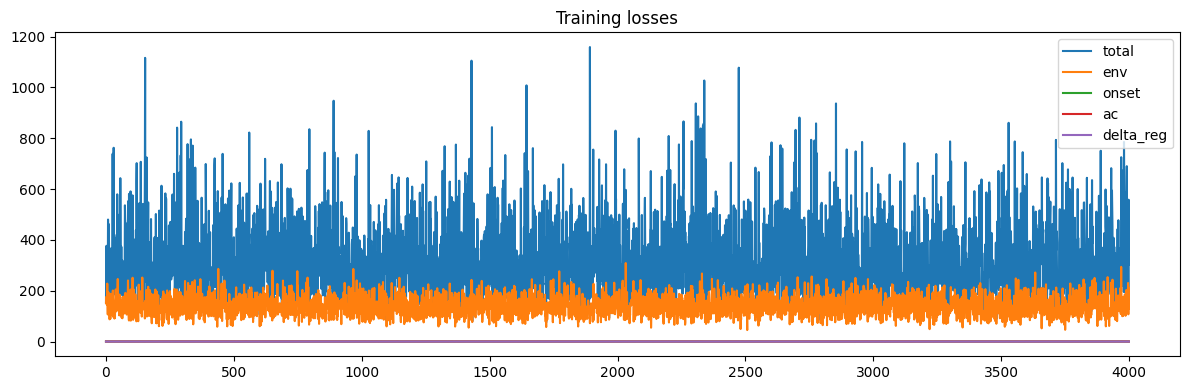

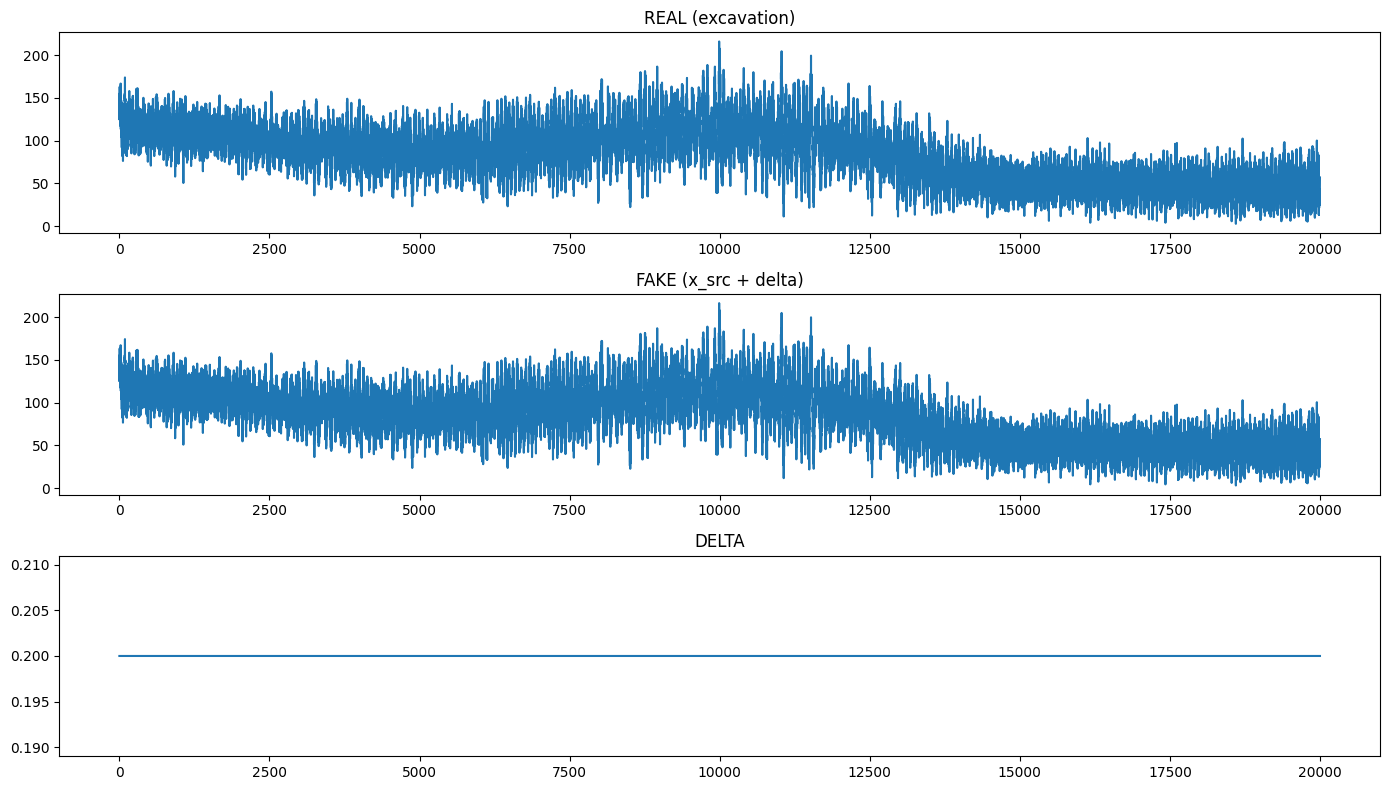

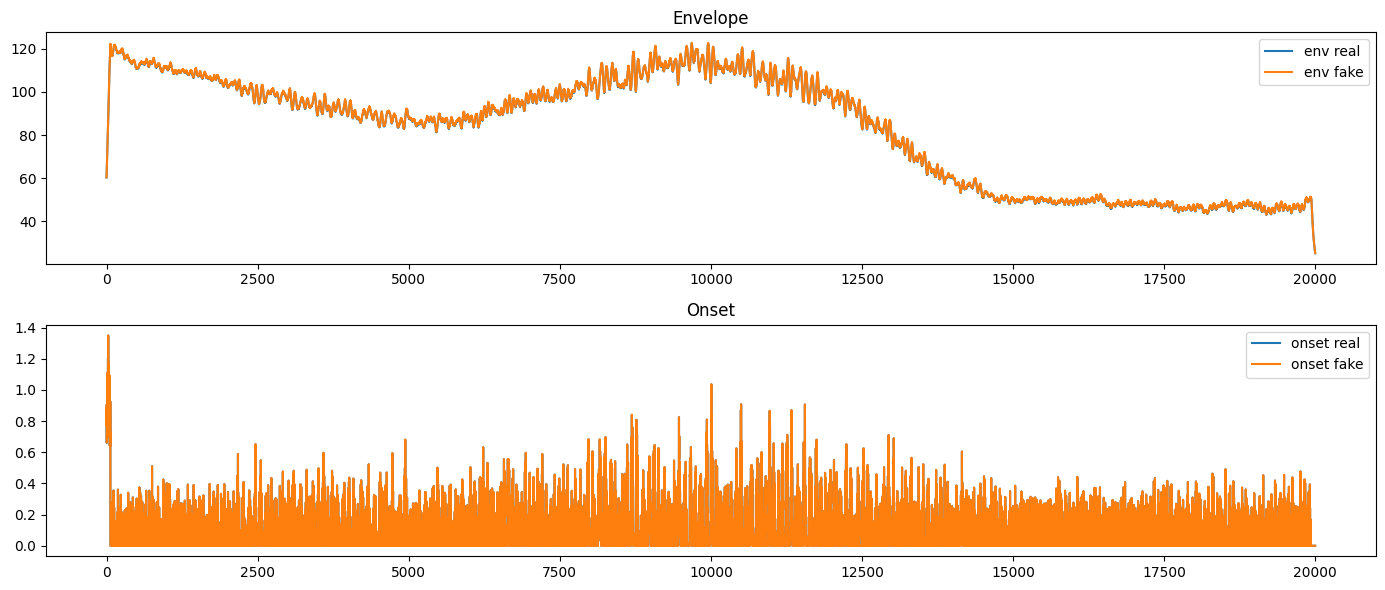

In [11]:
def plot_losses(hist):
    plt.figure(figsize=(12,4))
    plt.plot(hist["total"], label="total")
    plt.plot(hist["env"], label="env")
    plt.plot(hist["onset"], label="onset")
    plt.plot(hist["ac"], label="ac")
    plt.plot(hist["delta"], label="delta_reg")
    plt.legend(); plt.title("Training losses"); plt.tight_layout(); plt.show()

def generate_one(x_src_np):
    x_src = tf.convert_to_tensor(x_src_np[None,:,None], tf.float32)
    z = tf.random.normal((1, WINDOW_SIZE, LATENT_CH))
    delta = GEN([x_src, z], training=False)
    x_fake = x_src + delta
    return (x_fake[0,:,0].numpy(), delta[0,:,0].numpy())

plot_losses(hist)

row = exc_df.sample(1).iloc[0]
real = _load_signal_from_row(row, WINDOW_SIZE).astype(np.float32)
fake, delta = generate_one(real)

plt.figure(figsize=(14,8))
plt.subplot(3,1,1); plt.plot(real);  plt.title("REAL (excavation)")
plt.subplot(3,1,2); plt.plot(fake);  plt.title("FAKE (x_src + delta)")
plt.subplot(3,1,3); plt.plot(delta); plt.title("DELTA")
plt.tight_layout(); plt.show()

# Envelope & onset karşılaştırma
er = envelope(tf.convert_to_tensor(real[None,:,None])).numpy()[0,:,0]
ef = envelope(tf.convert_to_tensor(fake[None,:,None])).numpy()[0,:,0]
or_ = onset(tf.convert_to_tensor(er[None,:,None])).numpy()[0,:,0]
of_ = onset(tf.convert_to_tensor(ef[None,:,None])).numpy()[0,:,0]

plt.figure(figsize=(14,6))
plt.subplot(2,1,1); plt.plot(er, label="env real"); plt.plot(ef, label="env fake"); plt.legend(); plt.title("Envelope")
plt.subplot(2,1,2); plt.plot(or_, label="onset real"); plt.plot(of_, label="onset fake"); plt.legend(); plt.title("Onset")
plt.tight_layout(); plt.show()


NameError: name 'r_gan' is not defined

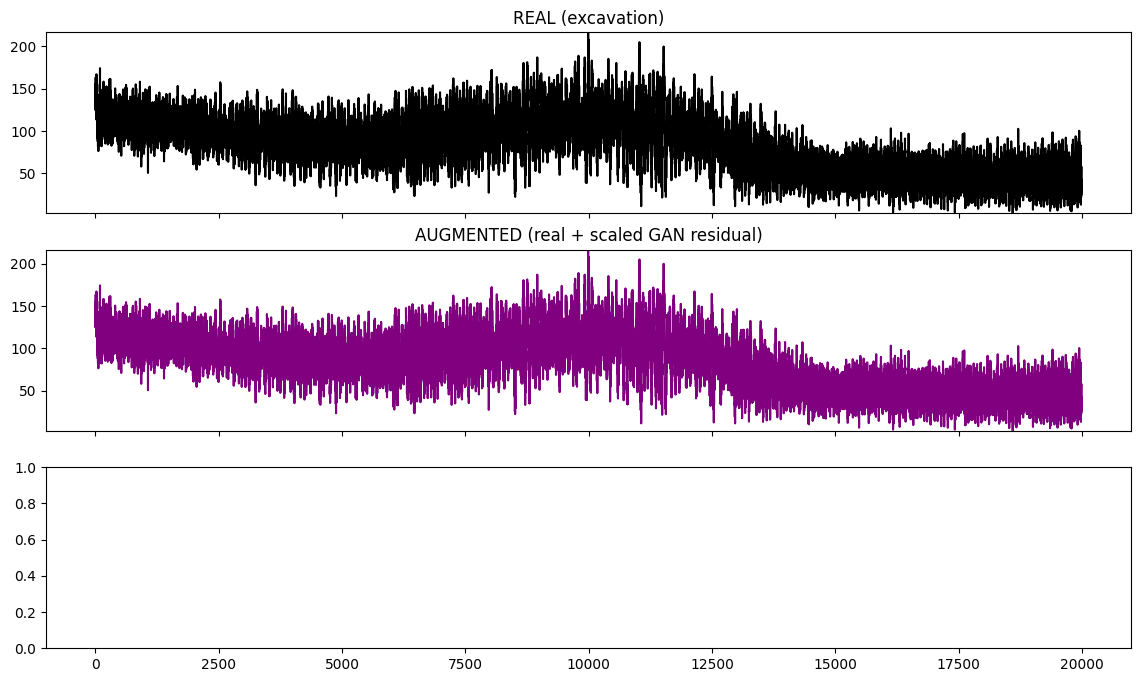

In [12]:
# CELL 11 — Waveform plot (real vs augmented) + residuals
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

ylim = (min(real.min(), fake.min()), max(real.max(), fake.max()))

ax1.plot(real, color="black")
ax1.set_title("REAL (excavation)")
ax1.set_ylim(ylim)

ax2.plot(fake, color="purple")
ax2.set_title("AUGMENTED (real + scaled GAN residual)")
ax2.set_ylim(ylim)

ax3.plot(r_gan, color="red")
ax3.set_title("GAN residual (scaled)")

plt.tight_layout()
plt.show()


In [ ]:
# CELL 12 — Batch-averaged PSD comparison (real residual vs GAN residual)
def mean_psd(residuals):
    Ps = []
    for r in residuals:
        x = r - np.mean(r)
        X = np.fft.rfft(x)
        Ps.append(np.abs(X)**2)
    return np.mean(Ps, axis=0)

# collect
N = 16
real_residuals = []
gan_residuals = []

# choose a fixed anchor real signal for fair comparison
anchor_row = exc_df.sample(1, random_state=RNG_SEED).iloc[0]
anchor = _load_signal_from_row(anchor_row, WINDOW_SIZE).astype(np.float32)

for _ in range(N):
    # real residual
    row2 = exc_df.sample(1).iloc[0]
    x2 = _load_signal_from_row(row2, WINDOW_SIZE).astype(np.float32)
    real_residuals.append(x2 - anchor)

    # gan residual (scaled)
    _, r_g, _, _ = augment_one(anchor)
    gan_residuals.append(r_g)

P_real = mean_psd(real_residuals)
P_gan  = mean_psd(gan_residuals)

plt.figure(figsize=(14,4))
plt.semilogy(P_real + 1e-12, label="REAL residual mean PSD")
plt.semilogy(P_gan  + 1e-12, label="GAN residual mean PSD")
plt.legend()
plt.title("Residual PSD (batch-averaged, absolute power, log scale)")
plt.tight_layout()
plt.show()


NameError: name 'RNG_SEED' is not defined

In [ ]:
# CELL 13 — Save / Load weights (offline, checkpoints)
WEIGHTS_DIR = DATA_FOLDER / "gan_weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

weights_path = WEIGHTS_DIR / f"residual_gan_{LABEL}_norm.keras"
GEN.save_weights(weights_path)
print("Saved:", weights_path)



Saved: /tf/start_training/data/signal/2025-11-27_5clf_best_data/gan_weights/residual_gan_excavation_norm.keras


In [ ]:
# ===============================
# Residual GAN fine-tuning loop
# ===============================

# ---- güvenli ayarlar ----
N_STEPS = 300            # 200–300 yeterli
PRINT_EVERY = 50
LR = 1e-5

# ---- model trainable açık mı? ----
for layer in GEN.layers:
    layer.trainable = True
GEN.trainable = True

print("Trainable weights:", len(GEN.trainable_weights))

# ---- optimizer YENİDEN ----
opt = tf.keras.optimizers.Adam(
    learning_rate=LR,
    beta_1=0.5,
    beta_2=0.9
)

# ---- loss logları ----
loss_hist = []
fft_hist  = []
rms_hist  = []
alpha_hist = []

# ---- sabit bir real örnek (sanity check için) ----
real_row = exc_df.sample(1, random_state=RNG_SEED).iloc[0]
real_ref = _load_signal_from_row(real_row, WINDOW_SIZE).astype(np.float32)
def fft_mag_loss(r_gan, r_real):
    """
    Log-magnitude FFT loss for residual matching.
    r_gan, r_real: (1, T, 1)
    """
    r_gan = tf.squeeze(r_gan, axis=-1)   # (1, T)
    r_real = tf.squeeze(r_real, axis=-1) # (1, T)

    # FFT
    Fg = tf.signal.rfft(r_gan)
    Fr = tf.signal.rfft(r_real)

    # log magnitude
    Mg = tf.math.log1p(tf.abs(Fg))
    Mr = tf.math.log1p(tf.abs(Fr))

    return tf.reduce_mean(tf.abs(Mg - Mr))

# ===============================
# TRAIN LOOP
# ===============================
for step in range(N_STEPS):

    # --- batch seç ---
    row1 = exc_df.sample(1).iloc[0]
    row2 = exc_df.sample(1).iloc[0]

    x1 = _load_signal_from_row(row1, WINDOW_SIZE).astype(np.float32)
    x2 = _load_signal_from_row(row2, WINDOW_SIZE).astype(np.float32)

    r_real = (x2 - x1).astype(np.float32)

    x1_tf = tf.convert_to_tensor(x1[None, :, None])
    r_real_tf = tf.convert_to_tensor(r_real[None, :, None])

    # normalize residual
    r_real_n, r_mean, r_std = normalize_residual(r_real_tf)

    z = tf.random.normal((1, WINDOW_SIZE, LATENT_CH))

    with tf.GradientTape() as tape:
        r_gan_n = GEN([x1_tf, z], training=True)
        r_gan = denormalize_residual(r_gan_n, r_mean, r_std)

        # --- losses ---
        loss_fft = fft_mag_loss(r_gan, r_real_tf)
        loss_rms = tf.abs(
            tf.sqrt(tf.reduce_mean(r_gan**2)) -
            tf.sqrt(tf.reduce_mean(r_real_tf**2))
        )

        loss = loss_fft + loss_rms

    grads = tape.gradient(loss, GEN.trainable_weights)
    opt.apply_gradients(zip(grads, GEN.trainable_weights))

    # ---- logging ----
    loss_hist.append(float(loss))
    fft_hist.append(float(loss_fft))
    rms_hist.append(float(loss_rms))

    # ---- sanity check ----
    if step % PRINT_EVERY == 0:
        fake, r_gan_ex, r_real_ex, alpha = augment_one(real_ref)

        alpha_hist.append(alpha)

        print(
            f"[{step}] "
            f"loss={loss:.4f} "
            f"fft={loss_fft:.4f} "
            f"rms={loss_rms:.4f} | "
            f"RMS(n) gan={rms_np(r_gan_ex):.3f} real=1.000 | "
            f"alpha={alpha:.3f}"
        )

        # kırmızı bayrak
        if rms_np(r_gan_ex) > 1.5 or alpha > 1.5:
            print("⚠️  STOP: residual out of control")
            break
GEN.save_weights("residual_wavegan_excavation_finetuned_v2.keras")

Trainable weights: 10


2025-12-16 08:46:10.111054: I external/local_xla/xla/service/service.cc:168] XLA service 0x40cebf10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-16 08:46:10.111079: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-12-16 08:46:10.125040: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1765874770.238928  964166 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[0] loss=1772.4998 fft=1.4270 rms=1771.0728 | RMS(n) gan=0.068 real=1.000 | alpha=0.600
[50] loss=79.3524 fft=1.6067 rms=77.7456 | RMS(n) gan=0.067 real=1.000 | alpha=0.600
[100] loss=4.1008 fft=2.0500 rms=2.0508 | RMS(n) gan=0.067 real=1.000 | alpha=0.600
[150] loss=29.5511 fft=1.3606 rms=28.1904 | RMS(n) gan=0.067 real=1.000 | alpha=0.600
[200] loss=89.4266 fft=0.7071 rms=88.7195 | RMS(n) gan=0.065 real=1.000 | alpha=0.600
[250] loss=1.0215 fft=0.8124 rms=0.2091 | RMS(n) gan=0.065 real=1.000 | alpha=0.600


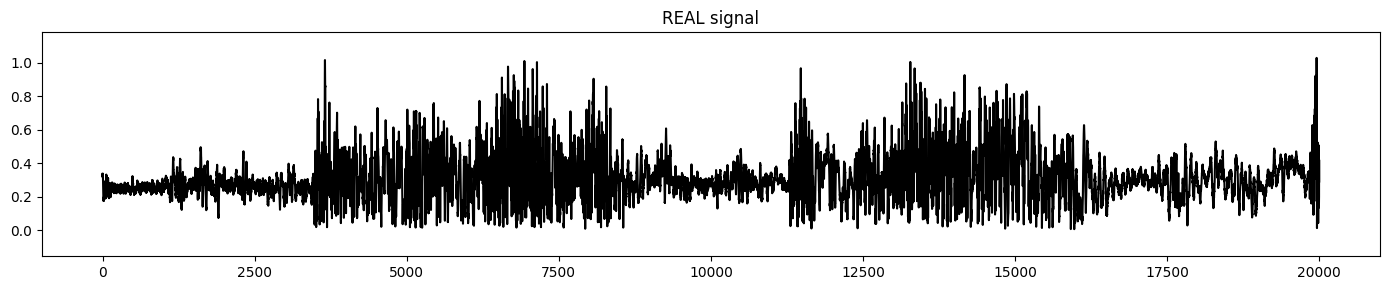

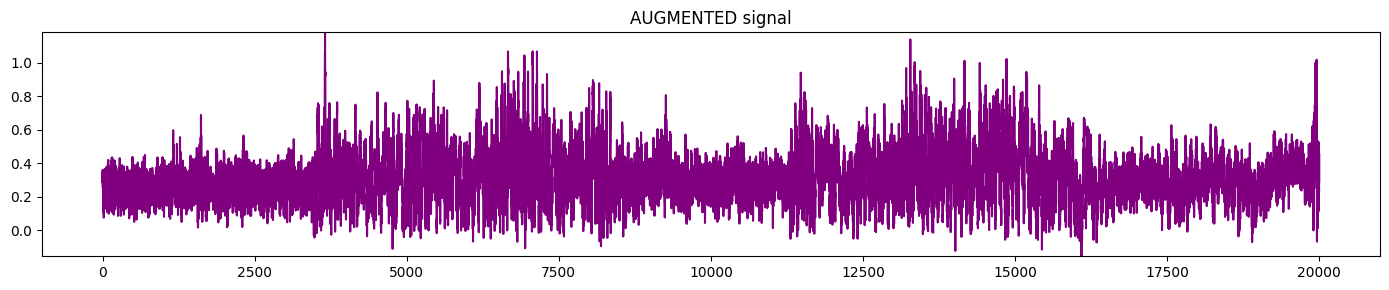

<Figure size 1400x300 with 0 Axes>

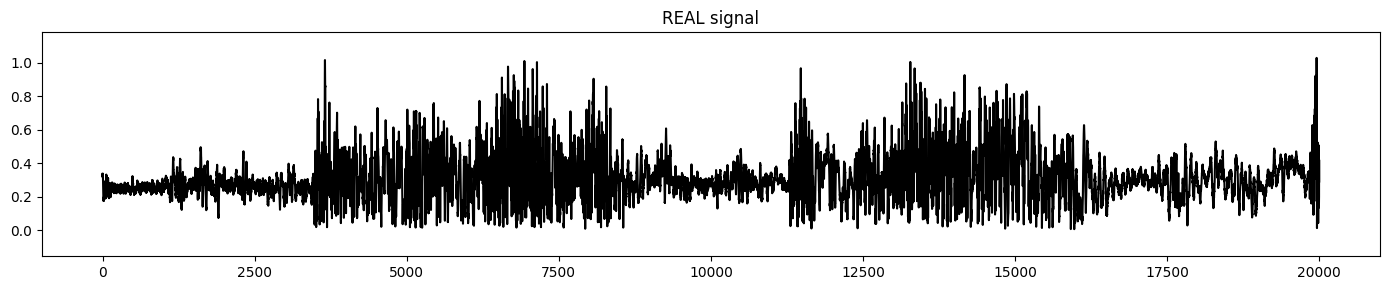

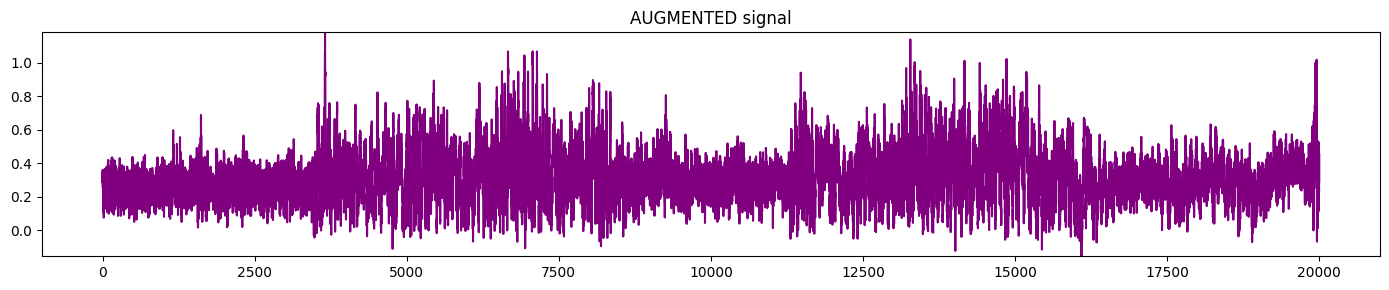

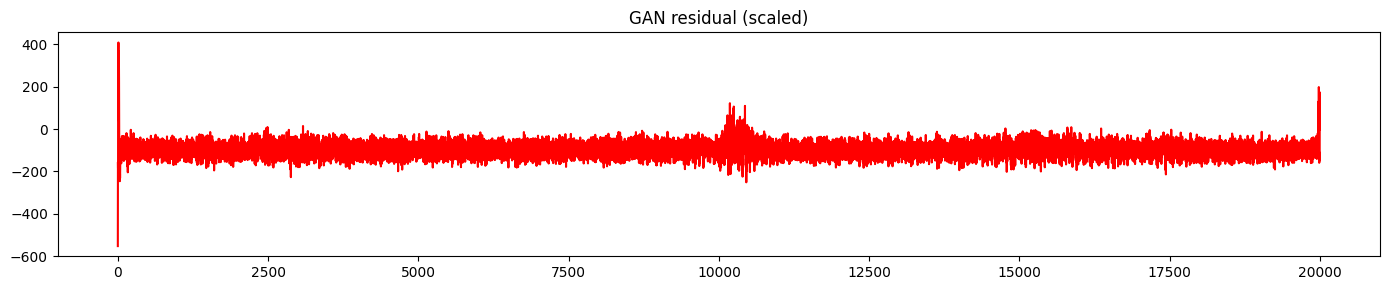

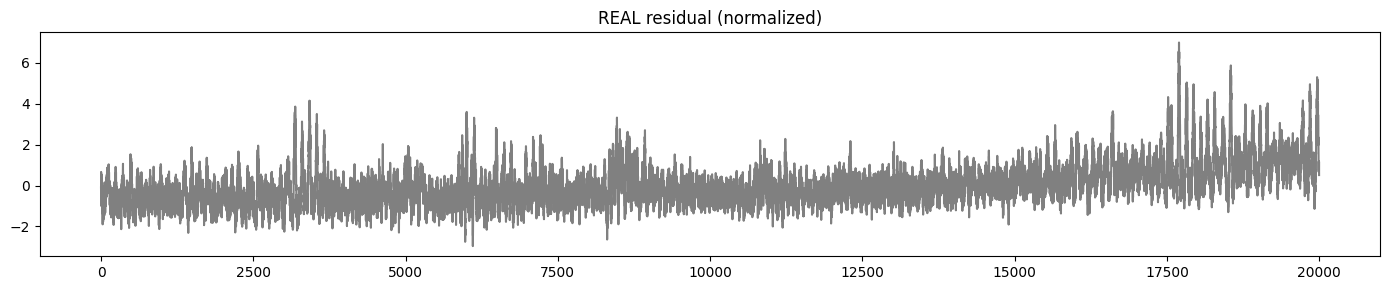

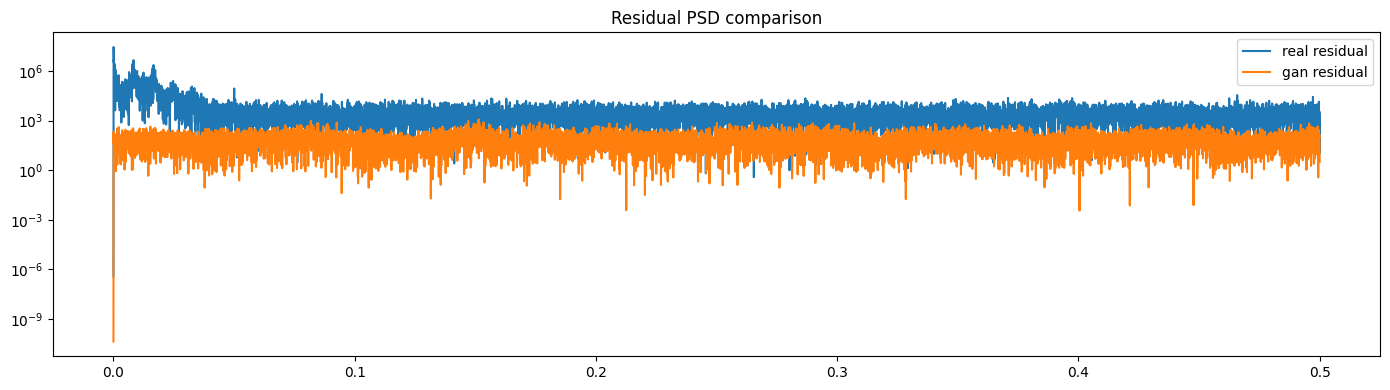

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_psd(x, label, fs=1.0):
    X = np.fft.rfft(x)
    psd = np.abs(X)**2
    freqs = np.fft.rfftfreq(len(x), d=1/fs)
    plt.semilogy(freqs, psd + 1e-12, label=label)

# ---- ortak y-lim (real vs fake) ----
ylim_rf = (
    min(real.min(), fake.min()),
    max(real.max(), fake.max())
)

# =========================
# 1️⃣ REAL
# =========================
plt.figure(figsize=(14,3))
plt.plot(real, color="black")
plt.title("REAL signal")
plt.ylim(ylim_rf)
plt.tight_layout()
plt.show()

# =========================
# 2️⃣ AUGMENTED (REAL + GAN residual)
# =========================
plt.figure(figsize=(14,3))
plt.plot(fake, color="purple")
plt.title("AUGMENTED signal")
plt.ylim(ylim_rf)
plt.tight_layout()
plt.show()

# =========================
# 3️⃣ GAN RESIDUAL (scaled)
# =========================
plt.figure(figsize=(14,3))
import matplotlib.pyplot as plt

def plot_psd(x, label, fs=1.0):
    X = np.fft.rfft(x)
    psd = np.abs(X)**2
    freqs = np.fft.rfftfreq(len(x), d=1/fs)
    plt.semilogy(freqs, psd + 1e-12, label=label)

# ---- ortak y-lim (real vs fake) ----
ylim_rf = (
    min(real.min(), fake.min()),
    max(real.max(), fake.max())
)

# =========================
# 1️⃣ REAL
# =========================
plt.figure(figsize=(14,3))
plt.plot(real, color="black")
plt.title("REAL signal")
plt.ylim(ylim_rf)
plt.tight_layout()
plt.show()

# =========================
# 2️⃣ AUGMENTED (REAL + GAN residual)
# =========================
plt.figure(figsize=(14,3))
plt.plot(fake, color="purple")
plt.title("AUGMENTED signal")
plt.ylim(ylim_rf)
plt.tight_layout()
plt.show()

# =========================
# 3️⃣ GAN RESIDUAL (scaled)
# =========================
plt.figure(figsize=(14,3))
# handle TF tensor or numpy array, and squeeze to 1D
r_gan_arr = r_gan.numpy() if hasattr(r_gan, "numpy") else np.asarray(r_gan)
plt.plot(np.squeeze(r_gan_arr), color="red")
plt.title("GAN residual (scaled)")
plt.tight_layout()
plt.show()

# =========================
# 4️⃣ REAL RESIDUAL (normalized)
# =========================
plt.figure(figsize=(14,3))
# use the normalized 1D residual arrays (r_real_ex and r_gan_ex) to avoid indexing errors
plt.plot(r_real_ex, color="gray")
plt.title("REAL residual (normalized)")
plt.tight_layout()
plt.show()

# =========================
# 5️⃣ PSD: residual comparison
# =========================
plt.figure(figsize=(14,4))
# compare PSDs using the 1D numpy arrays
plot_psd(r_real_ex, "real residual")
plot_psd(r_gan_ex,  "gan residual")
plt.legend()
plt.title("Residual PSD comparison")
plt.tight_layout()
plt.show()


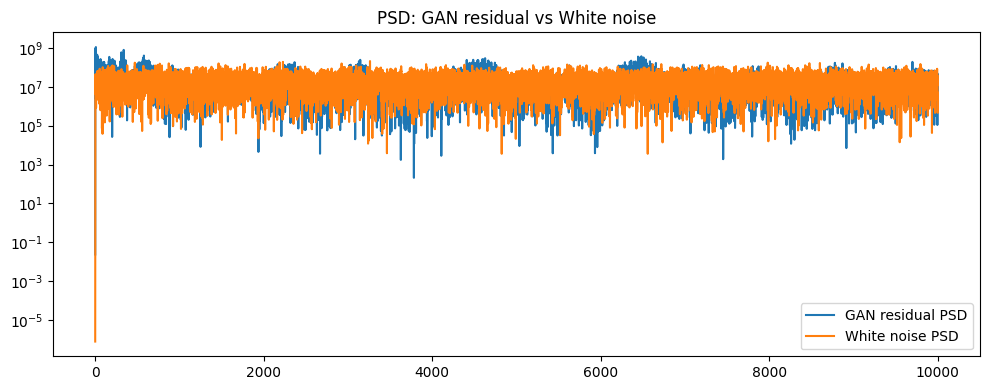

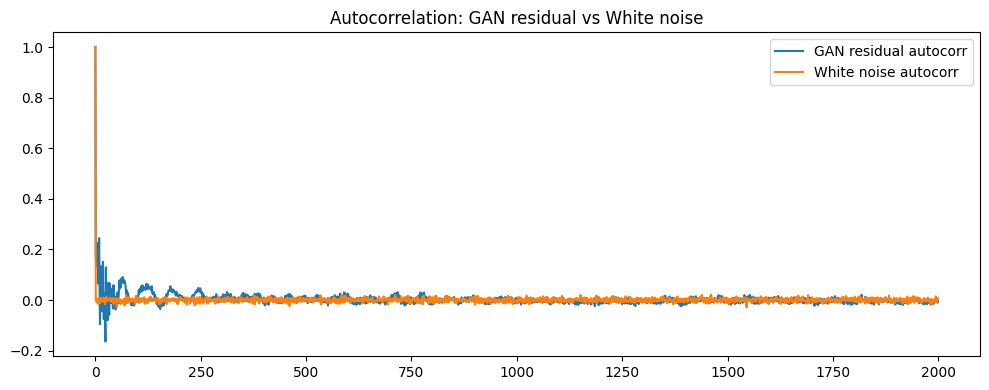

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def autocorr(x, max_lag=2000):
    x = x - np.mean(x)
    ac = np.correlate(x, x, mode="full")
    ac = ac[len(ac)//2:len(ac)//2 + max_lag]
    return ac / (ac[0] + 1e-12)

def psd(x):
    X = np.fft.rfft(x - np.mean(x))
    return np.abs(X)**2

# GAN residual: r_gan (scaled)
g = np.squeeze(r_gan.numpy())   # (T,)

# White noise same std
w = np.random.normal(0, np.std(g), size=g.shape).astype(np.float32)

# PSD
Pg, Pw = psd(g), psd(w)

plt.figure(figsize=(10,4))
plt.semilogy(Pg + 1e-12, label="GAN residual PSD")
plt.semilogy(Pw + 1e-12, label="White noise PSD")
plt.legend(); plt.title("PSD: GAN residual vs White noise"); plt.tight_layout(); plt.show()

# Autocorr
Ag, Aw = autocorr(g), autocorr(w)

plt.figure(figsize=(10,4))
plt.plot(Ag, label="GAN residual autocorr")
plt.plot(Aw, label="White noise autocorr")
plt.legend(); plt.title("Autocorrelation: GAN residual vs White noise"); plt.tight_layout(); plt.show()


mean(isclose(xs,xt)): 2.5e-05
MSE per-sample: [[34708.664 ]
 [66007.28  ]
 [17301.666 ]
 [ 9923.52  ]
 [16035.792 ]
 [20207.078 ]
 [75171.17  ]
 [ 4135.3994]]
corr per-sample: [[-0.07539299]
 [-0.18137166]
 [ 0.0143103 ]
 [-0.01196207]
 [-0.03576881]
 [-0.03213876]
 [-0.03590107]
 [-0.04061398]]


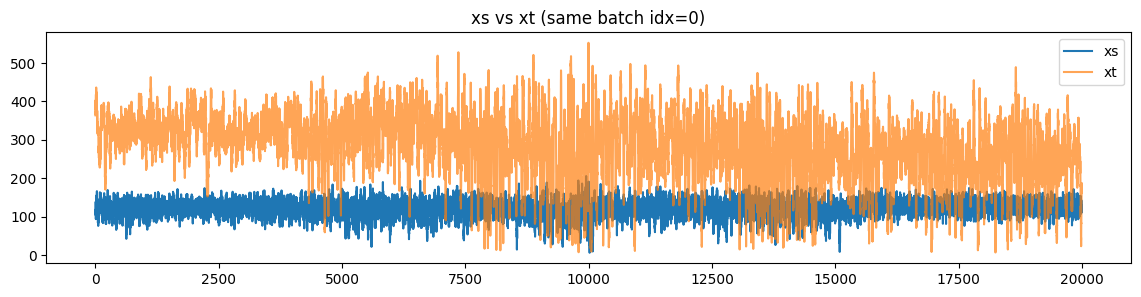

In [13]:
# QUICK SANITY: xs ve xt aynı mı?
xs, _  = sample_exc_batch(exc_df, batch=8, window=WINDOW_SIZE)
_,  xt = sample_exc_batch(exc_df, batch=8, window=WINDOW_SIZE)

# batch içinde eşleşen var mı?
eq = np.mean(np.isclose(xs, xt))
print("mean(isclose(xs,xt)):", eq)

# her sample için MSE
mse = ((xs - xt)**2).mean(axis=1)
print("MSE per-sample:", mse)

# correlation
def corr(a,b):
    a=a - a.mean(axis=1, keepdims=True)
    b=b - b.mean(axis=1, keepdims=True)
    return (a*b).mean(axis=1)/(a.std(axis=1)*b.std(axis=1)+1e-9)

print("corr per-sample:", corr(xs, xt))

# ilk örneği üst üste plotla
i=0
plt.figure(figsize=(14,3))
plt.plot(xs[i], label="xs")
plt.plot(xt[i], label="xt", alpha=0.7)
plt.legend(); plt.title("xs vs xt (same batch idx=0)"); plt.show()
